In [1]:
import copy
import os
from datetime import datetime
from math import ceil, floor

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from sklearn.metrics import accuracy_score, confusion_matrix
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms

# For reproducibility
torch.manual_seed(123)
np.random.seed(123)
torch.cuda.manual_seed_all(123)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
# Check files existence and quick sanity check
for path in [
    "data/localization_train.pt",
    "data/localization_val.pt",
    "data/localization_test.pt",
]:
    print("\n---", path, "---")
    print("exists:", os.path.exists(path))
    if os.path.exists(path):
        print("size:", os.path.getsize(path), "bytes")
        with open(path, "rb") as f:
            head = f.read(64)
        print("first 64 bytes:", head)


--- data/localization_train.pt ---
exists: True
size: 685714707 bytes
first 64 bytes: b'PK\x03\x04\x00\x00\x08\x08\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x1b\x00\x07\x00localization_train/data.pklFB\x03\x00ZZZ'

--- data/localization_val.pt ---
exists: True
size: 76191499 bytes
first 64 bytes: b'PK\x03\x04\x00\x00\x08\x08\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x19\x00\t\x00localization_val/data.pklFB\x05\x00ZZZZZ'

--- data/localization_test.pt ---
exists: True
size: 126985103 bytes
first 64 bytes: b'PK\x03\x04\x00\x00\x08\x08\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x1a\x00\x08\x00localization_test/data.pklFB\x04\x00ZZZZ'


# Model definition

In [ ]:
# Select training device
device = (torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu'))
print(f"Training on device {device}.")

# Model Definition
# Define a neural network for localization and classification
class Localizer(nn.Module):
    def __init__(self, C=10):
        super().__init__()
        self.C = C # Number of classes to predict

        # 1) Feature extractor
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)

        # 2) Make output size independent of image size
        self.gap = nn.AdaptiveAvgPool2d((4, 4))  

        # 3) Prediction head
        self.fc1 = nn.Linear(8 * 4 * 4, 32)
        self.fc2 = nn.Linear(32, C + 5)          

    def forward(self, x):
        
        x = F.relu(self.conv1(x))   
        x = self.pool(x)            

        x = self.gap(x)             
        x = x.view(x.size(0), -1)   

        x = F.relu(self.fc1(x))    
        out = self.fc2(x)           

        return out

model = Localizer(C=10).to(device)
print(model)

Training on device cuda.
Localizer(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (gap): AdaptiveAvgPool2d(output_size=(4, 4))
  (fc1): Linear(in_features=128, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=15, bias=True)
)


## Localization


In [ ]:
# Calculation of the localization loss

def localization_loss(y_pred, y_true, C=10, lambda_bbox=1.0):
    
    pc_true = y_true[:, 0].float()
    bbox_true = y_true[:, 1:5].float()
    c_true = y_true[:, 5].long()

    pc_logit = y_pred[:, 0]
    bbox_pred = torch.sigmoid(y_pred[:, 1:5])   
    class_logits = y_pred[:, 5:5+C]

    bce = nn.BCEWithLogitsLoss(reduction='none')
    mse = nn.MSELoss(reduction='none')
    ce  = nn.CrossEntropyLoss(reduction='none')

    LA = bce(pc_logit, pc_true)   # objectness loss for all samples

    has_obj = (pc_true > 0.5)

    LB = torch.zeros_like(LA) # Weighted bounding box loss for all samples
    LC = torch.zeros_like(LA) # Classification loss for positive samples

    if has_obj.any():
        LB_pos = mse(bbox_pred[has_obj], bbox_true[has_obj]).mean(dim=1)
        LC_pos = ce(class_logits[has_obj], c_true[has_obj])

        LB[has_obj] = LB_pos
        LC[has_obj] = LC_pos

    L = LA + lambda_bbox * LB + LC # Sum of components loss with weight parameter lambda
    return L.mean()

### Load data and preprocessing

In [ ]:
# Function for loading the localization datasets

def load_localization_dataset(path):
    obj = torch.load(path, map_location="cpu", weights_only=False)

    if isinstance(obj, TensorDataset):
        return obj

    if isinstance(obj, (tuple, list)) and len(obj) == 2:
        X, y = obj
        if X.ndim == 3:
            X = X.unsqueeze(1)
        return TensorDataset(X.float(), y)

    if isinstance(obj, dict):
        X = obj.get("X", obj.get("x", obj.get("images", obj.get("data"))))
        y = obj.get("y", obj.get("Y", obj.get("labels", obj.get("targets"))))
        if X is None or y is None:
            raise KeyError(f"Could not find X/y in dict keys: {list(obj.keys())}")
        if X.ndim == 3:
            X = X.unsqueeze(1)
        return TensorDataset(X.float(), y)

    raise TypeError(f"Unsupported dataset format in {path}: {type(obj)}")


# Load datasets
train_ds = load_localization_dataset("data/localization_train.pt")
val_ds   = load_localization_dataset("data/localization_val.pt")
test_ds  = load_localization_dataset("data/localization_test.pt")

# Quick sanity check
X0, y0 = train_ds[0]
print("One sample X:", X0.shape, X0.dtype, "y:", y0.shape, y0.dtype)

# DataLoaders
batch_size = 64
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

One sample X: torch.Size([1, 48, 60]) torch.float32 y: torch.Size([6]) torch.float32


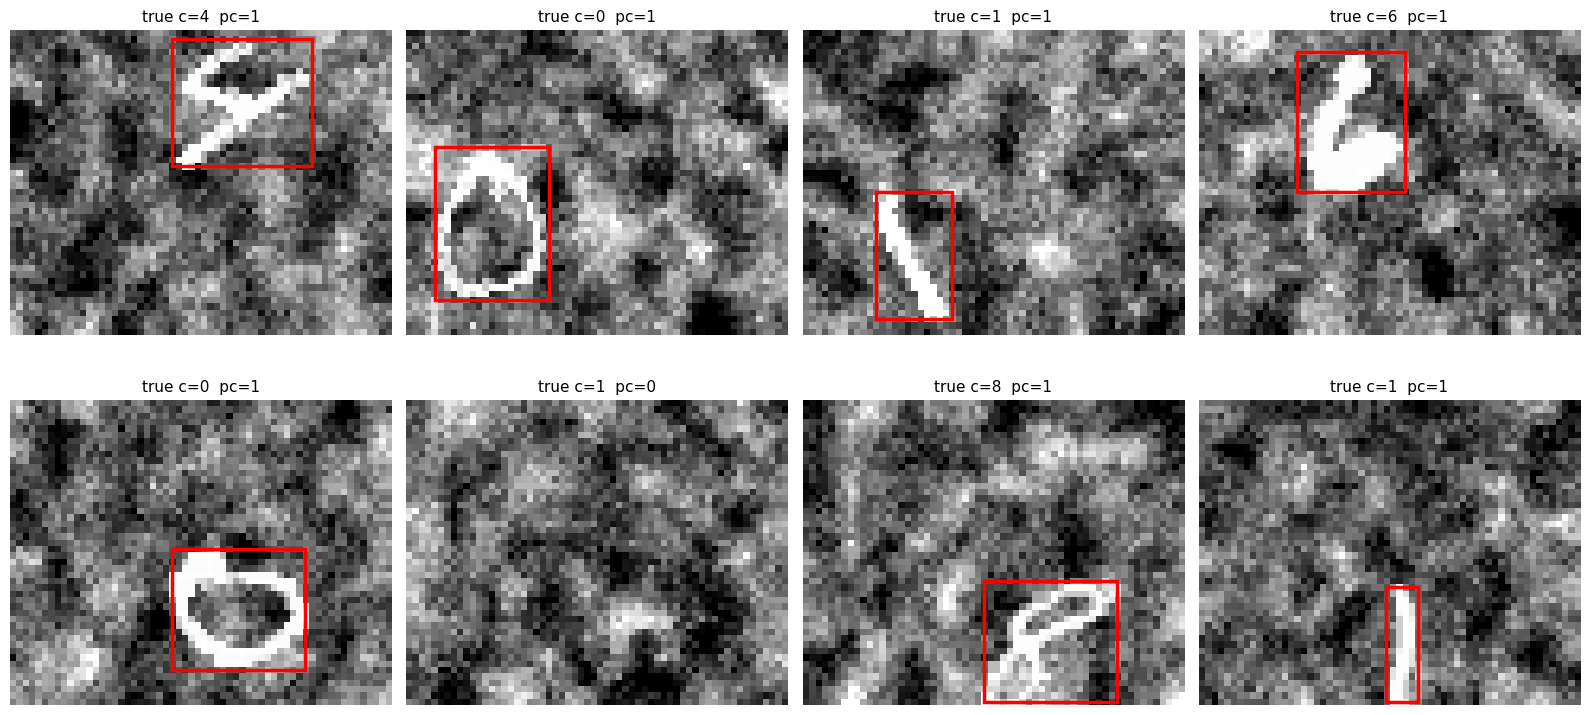

In [ ]:
# Draw true bounding boxes
def draw_true_boxes_red(dataset, n=12, cols=4, show_axes=False, linewidth=2.5,
                        box_color="red", empty_color="0.6"):
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*4))
    axes = np.array(axes).reshape(-1)

    for i in range(rows * cols):
        ax = axes[i]
        ax.set_xticks([])
        ax.set_yticks([])
        if not show_axes:
            ax.set_axis_off()

        if i >= n:
            ax.set_visible(False)
            continue

        x, y = dataset[i]
        img = x.squeeze(0).numpy()
        pc, cx, cy, w, h, c = y.tolist()

        H, W = img.shape
        ax.imshow(img, cmap="gray", interpolation="nearest")
        ax.set_title(f"true c={int(c)}  pc={int(pc)}", fontsize=11)

        # Colorize the subplot border (frame)
        frame_color = box_color if pc > 0.5 else empty_color
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(2.0)
            spine.set_edgecolor(frame_color)

        # Draw bbox if object exists
        if pc > 0.5:
            x1 = (cx - w/2) * W
            y1 = (cy - h/2) * H
            rect_w = w * W
            rect_h = h * H

            rect = patches.Rectangle(
                (x1, y1), rect_w, rect_h,
                fill=False, linewidth=linewidth, edgecolor=box_color
            )
            ax.add_patch(rect)

    plt.tight_layout()
    plt.show()

# Run the function
draw_true_boxes_red(train_ds, n=8, cols=4)

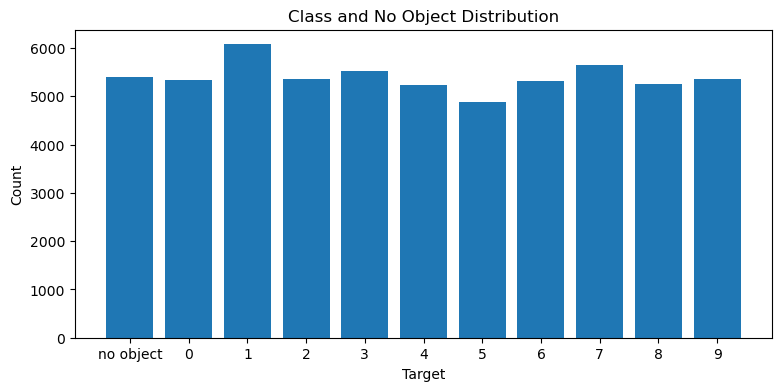

In [ ]:
# Explore class balance

def plot_class_counts(dataset):
    X, y = dataset.tensors
    pc = y[:, 0]
    c  = y[:, 5].long()

    mask_obj = pc > 0.5
    mask_noobj = ~mask_obj

    c_obj = c[mask_obj]
    counts = torch.bincount(c_obj, minlength=10).cpu().numpy()
    n_noobj = int(mask_noobj.sum().item())

    plt.figure(figsize=(9,4))
    labels = ["no object"] + [str(i) for i in range(10)]
    values = [n_noobj] + counts.tolist()

    plt.bar(range(11), values)
    plt.xticks(range(11), labels)
    plt.xlabel("Target")
    plt.ylabel("Count")
    plt.title("Class and No Object Distribution")
    plt.show()

plot_class_counts(train_ds)

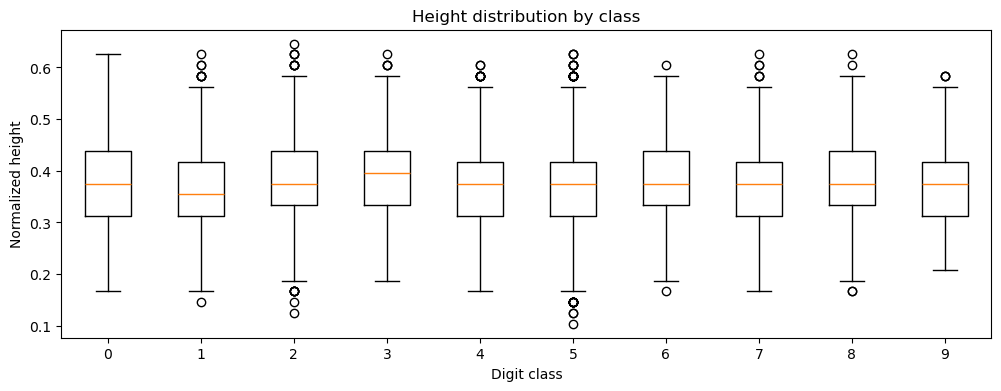

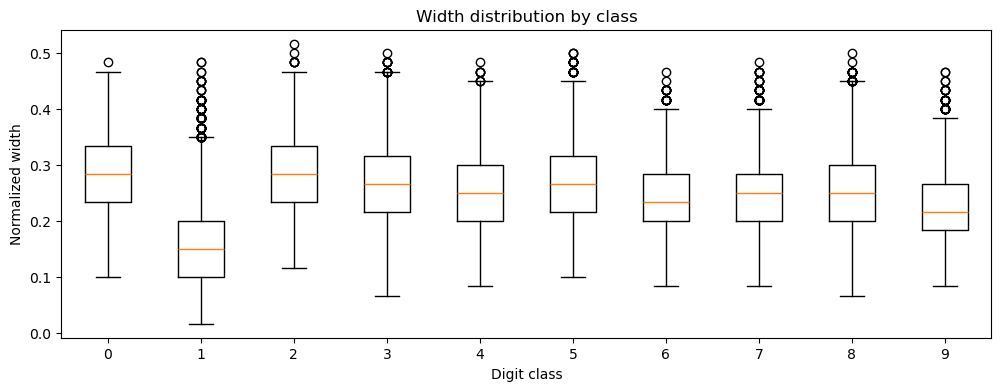

In [ ]:
# Plot width and height of bounding boxes distribution for sanity check

def plot_wh_boxplots(dataset):
    X, y = dataset.tensors
    pc = y[:, 0].cpu().numpy()
    w  = y[:, 3].cpu().numpy()
    h  = y[:, 4].cpu().numpy()
    c  = y[:, 5].long().cpu().numpy()

    mask = pc > 0.5
    w = w[mask]; h = h[mask]; c = c[mask]

    data_w = [w[c == k] for k in range(10)]
    data_h = [h[c == k] for k in range(10)]

    plt.figure(figsize=(12,4))
    plt.boxplot(data_h, tick_labels=list(range(10)))
    plt.xlabel("Digit class")
    plt.ylabel("Normalized height")
    plt.title("Height distribution by class")
    plt.show()

    plt.figure(figsize=(12,4))
    plt.boxplot(data_w, tick_labels=list(range(10)))
    plt.xlabel("Digit class")
    plt.ylabel("Normalized width")
    plt.title("Width distribution by class")
    plt.show()

    

plot_wh_boxplots(train_ds)

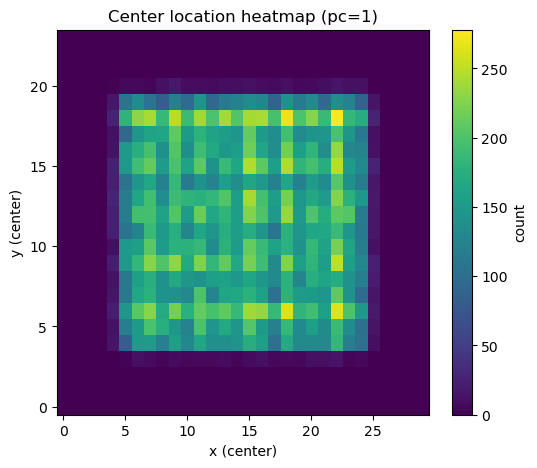

In [ ]:
# Plot center heatmap

def plot_center_heatmap(dataset, bins=(24, 30)):
    X, y = dataset.tensors
    pc = y[:, 0].cpu().numpy()
    cx = y[:, 1].cpu().numpy()
    cy = y[:, 2].cpu().numpy()

    mask = pc > 0.5
    cx = cx[mask]
    cy = cy[mask]

    H, xedges, yedges = np.histogram2d(cy, cx, bins=bins, range=[[0,1],[0,1]])  

    plt.figure(figsize=(6,5))
    plt.imshow(H, origin="lower", aspect="auto")
    plt.xlabel("x (center)")
    plt.ylabel("y (center)")
    plt.title("Center location heatmap (pc=1)")
    plt.colorbar(label="count")
    plt.show()

plot_center_heatmap(train_ds)

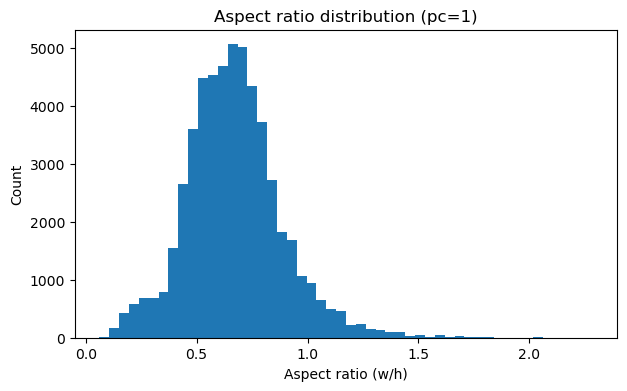

In [ ]:
# Plot width v height ratio

def plot_aspect_ratio(dataset):
    X, y = dataset.tensors
    pc = y[:, 0].cpu().numpy()
    w  = y[:, 3].cpu().numpy()
    h  = y[:, 4].cpu().numpy()

    mask = pc > 0.5
    ar = (w[mask] / (h[mask] + 1e-8))

    plt.figure(figsize=(7,4))
    plt.hist(ar, bins=50)
    plt.xlabel("Aspect ratio (w/h)")
    plt.ylabel("Count")
    plt.title("Aspect ratio distribution (pc=1)")
    plt.show()

plot_aspect_ratio(train_ds)

In [ ]:
# Sanity check for the localization datasets

def sanity_check_localization_dataset(dataset, name="dataset", C=10, max_print=5):
    print(f"\n--- Sanity check: {name} ---")

    if hasattr(dataset, "tensors"):
        X, y = dataset.tensors
    else:
        xs, ys = zip(*[dataset[i] for i in range(min(len(dataset), 1000))])
        X = torch.stack(xs)
        y = torch.stack(ys)

    print("X shape:", tuple(X.shape), "dtype:", X.dtype) # Shape
    print("y shape:", tuple(y.shape), "dtype:", y.dtype)

    assert X.ndim == 4 and X.shape[1] == 1, "Expected X of shape (N,1,H,W)"
    assert y.ndim == 2 and y.shape[1] == 6, "Expected y of shape (N,6)"

    x_nan = torch.isnan(X).sum().item() # Check for NaN/Inf
    x_inf = torch.isinf(X).sum().item()
    y_nan = torch.isnan(y).sum().item()
    y_inf = torch.isinf(y).sum().item()
    print(f"X: NaN={x_nan}, Inf={x_inf}")
    print(f"y: NaN={y_nan}, Inf={y_inf}")

    x_min, x_max = X.min().item(), X.max().item() # Check min and max value
    x_mean, x_std = X.mean().item(), X.std().item() # Check std and mean
    print(f"X stats: min={x_min:.4f}, max={x_max:.4f}, mean={x_mean:.4f}, std={x_std:.4f}")

    pc = y[:, 0]
    bbox = y[:, 1:5]
    c = y[:, 5]

    unique_pc = torch.unique(pc)
    print("Unique pc:", unique_pc.tolist())
    pc_nonbinary = ((pc != 0.0) & (pc != 1.0)).sum().item()
    print("pc non-binary count:", pc_nonbinary)

    c_long = c.long()
    c_not_intlike = (c != c_long.float()).sum().item()
    print("class not int-like count:", c_not_intlike)

    c_min, c_max = c_long.min().item(), c_long.max().item()
    out_of_range = ((c_long < 0) | (c_long >= C)).sum().item()
    print(f"class range: min={c_min}, max={c_max}")
    print("class out-of-range count:", out_of_range)

    bbox_min = bbox.min(dim=0).values
    bbox_max = bbox.max(dim=0).values
    print("bbox min [x,y,w,h]:", bbox_min.tolist())
    print("bbox max [x,y,w,h]:", bbox_max.tolist())

    # Keep only samples that contain an object
    mask = pc > 0.5
    n_obj = mask.sum().item()
    print("Num objects (pc=1):", n_obj, "/", len(dataset))

    # Check box geometry only where pc=1
    if n_obj > 0:
        bbox_obj = bbox[mask]
        x_c, y_c, w, h = bbox_obj[:, 0], bbox_obj[:, 1], bbox_obj[:, 2], bbox_obj[:, 3]

        nonpos_w = (w <= 0).sum().item()
        nonpos_h = (h <= 0).sum().item()
        print("non-positive w count:", nonpos_w) # Check for nonpositives
        print("non-positive h count:", nonpos_h)

        x1 = x_c - w/2
        x2 = x_c + w/2
        y1 = y_c - h/2
        y2 = y_c + h/2
        oob = ((x1 < 0) | (y1 < 0) | (x2 > 1) | (y2 > 1)).sum().item() # Check out of bounds
        print("out-of-bounds boxes count (pc=1):", oob) 

        if oob > 0 or nonpos_w > 0 or nonpos_h > 0:
            bad_idx = torch.where(mask & ((x1 < 0) | (y1 < 0) | (x2 > 1) | (y2 > 1) | (w <= 0) | (h <= 0)))[0]
            if bad_idx.numel() > 0:
                print(f"Example bad indices (up to {max_print}):", bad_idx[:max_print].tolist())

    print("--- Done ---")


# Run checks
sanity_check_localization_dataset(train_ds, name="train", C=10)
sanity_check_localization_dataset(val_ds,   name="val",   C=10)
sanity_check_localization_dataset(test_ds,  name="test",  C=10)    


--- Sanity check: train ---
X shape: (59400, 1, 48, 60) dtype: torch.float32
y shape: (59400, 6) dtype: torch.float32
X: NaN=0, Inf=0
y: NaN=0, Inf=0
X stats: min=0.0000, max=1.0000, mean=0.4171, std=0.2138
Unique pc: [0.0, 1.0]
pc non-binary count: 0
class not int-like count: 0
class range: min=0, max=9
class out-of-range count: 0
bbox min [x,y,w,h]: [-1.0, -1.0, -1.0, -1.0]
bbox max [x,y,w,h]: [0.8666666746139526, 0.8645833730697632, 0.5166666507720947, 0.6458333730697632]
Num objects (pc=1): 54000 / 59400
non-positive w count: 0
non-positive h count: 0
out-of-bounds boxes count (pc=1): 0
--- Done ---

--- Sanity check: val ---
X shape: (6600, 1, 48, 60) dtype: torch.float32
y shape: (6600, 6) dtype: torch.float32
X: NaN=0, Inf=0
y: NaN=0, Inf=0
X stats: min=0.0000, max=1.0000, mean=0.4169, std=0.2137
Unique pc: [0.0, 1.0]
pc non-binary count: 0
class not int-like count: 0
class range: min=0, max=9
class out-of-range count: 0
bbox min [x,y,w,h]: [-1.0, -1.0, -1.0, -1.0]
bbox max [x,

### Normalize Images

In [ ]:
# Compute mean and std from training dataset for normalization
def compute_mean_std_from_tensor_dataset(ds):
    X, _ = ds.tensors  
    X = X.float()
    mean = X.mean().item()
    std  = X.std().item()
    return mean, std

TRAIN_MEAN, TRAIN_STD = compute_mean_std_from_tensor_dataset(train_ds)
print("TRAIN_MEAN, TRAIN_STD:", TRAIN_MEAN, TRAIN_STD)

def normalize_dataset_in_memory(ds, mean, std):
    X, y = ds.tensors
    X = X.float()
    Xn = (X - mean) / (std + 1e-8)
    return TensorDataset(Xn, y)

train_ds_norm = normalize_dataset_in_memory(train_ds, TRAIN_MEAN, TRAIN_STD)
val_ds_norm   = normalize_dataset_in_memory(val_ds,   TRAIN_MEAN, TRAIN_STD)
test_ds_norm  = normalize_dataset_in_memory(test_ds,  TRAIN_MEAN, TRAIN_STD)

batch_size = 64
train_loader = DataLoader(train_ds_norm, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds_norm,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds_norm,  batch_size=batch_size, shuffle=False)

# Check
Xn_train, _ = train_ds_norm.tensors
print("Normalized train mean/std:", Xn_train.mean().item(), Xn_train.std().item())

TRAIN_MEAN, TRAIN_STD: 0.41708362102508545 0.2138432264328003
Normalized train mean/std: -5.683370929432385e-08 0.9999999403953552


### Training

In [ ]:
# Define models
class LocalizerV1(nn.Module):  # baseline (minimal model)
    def __init__(self, C=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, 3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.gap   = nn.AdaptiveAvgPool2d((4, 4))
        self.fc1   = nn.Linear(8 * 4 * 4, 32)
        self.fc2   = nn.Linear(32, C + 5)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = self.gap(x).view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

class LocalizerV2(nn.Module):  # deeper (more channels + more conv)
    def __init__(self, C=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2,2),  

            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2,2),  

            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
        )
        self.gap = nn.AdaptiveAvgPool2d((4, 4))  
        self.head = nn.Sequential(
            nn.Linear(64 * 4 * 4, 128), nn.ReLU(),
            nn.Linear(128, C + 5)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x).view(x.size(0), -1)
        return self.head(x)

class LocalizerV3(nn.Module):  # deeper + batchnorm + dropout (more stable)
    def __init__(self, C=10, p=0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
        )
        self.gap = nn.AdaptiveAvgPool2d((4, 4))
        self.head = nn.Sequential(
            nn.Linear(64 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(128, C + 5)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x).view(x.size(0), -1)
        return self.head(x)

In [ ]:
# Training for one epoch

def train_one_epoch_loss(model, loader, optimizer, device, C=10, lambda_bbox=1.0):
    model.train()
    
    total = 0.0 # Running sum of loss over all samples
    n = 0 # Running count over samples

    for X, y in loader: # Iterate over batches
        X = X.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        y_pred = model(X)
        loss = localization_loss(y_pred, y, C=C, lambda_bbox=lambda_bbox)
        loss.backward()
        optimizer.step()

        bs = X.size(0)
        total += loss.item() * bs
        n += bs

    return total / max(n, 1)

# Evaluation of one epoch
@torch.no_grad()
def eval_one_epoch_loss(model, loader, device, C=10, lambda_bbox=1.0):
    model.eval()
    total = 0.0
    n = 0

    for X, y in loader:
        X = X.to(device)
        y = y.to(device)

        y_pred = model(X)
        loss = localization_loss(y_pred, y, C=C, lambda_bbox=lambda_bbox)

        bs = X.size(0)
        total += loss.item() * bs
        n += bs

    return total / max(n, 1)

# Full training loop
def fit_loss_only(
    model,
    train_loader,
    val_loader,
    device,
    epochs=10,
    lr=1e-3,
    weight_decay=0.0,
    C=10,
    lambda_bbox=1.0,
    patience=3,
    min_delta=1e-4,
    min_epochs=5,
):
    # Create the optimizer
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )
    history = {"train_loss": [], "val_loss": []}

    best_val_loss = float("inf")
    best_model_state = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0

    for epoch in range(1, epochs + 1):
        tr_loss = train_one_epoch_loss(
            model, train_loader, optimizer, device, C=C, lambda_bbox=lambda_bbox
        )
        va_loss = eval_one_epoch_loss(
            model, val_loader, device, C=C, lambda_bbox=lambda_bbox
        )

        history["train_loss"].append(tr_loss) # Save losses
        history["val_loss"].append(va_loss)

        print(f"Epoch {epoch:02d} | train loss {tr_loss:.4f} | val loss {va_loss:.4f}") # Print status

        if va_loss < best_val_loss - min_delta:
            best_val_loss = va_loss
            best_model_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            print(f"  No significant improvement for {epochs_no_improve} epoch(s)")

        if epoch >= min_epochs and epochs_no_improve >= patience: # Early stopping after min epochs if patience violated
            print(f"Early stopping at epoch {epoch:02d}")
            break

    model.load_state_dict(best_model_state)
    return model, history

In [ ]:
C = 10 # Number of class
EPOCHS = 20 # Number of epochs

lambda_values = [1, 10, 20] # Hyperparameters
lr_values = [1e-4, 1e-3]
weight_decay_values = [0.0, 1e-4]

def build_models(C):
    # Models
    return {
        "V1_baseline": LocalizerV1(C=C), 
        "V2_deeper":   LocalizerV2(C=C),
        "V3_bn_drop":  LocalizerV3(C=C, p=0.3),
    }

all_results = {} # Dictionary to store results

for lambda_bbox in lambda_values:
    print(f"\n\n######## lambda_bbox = {lambda_bbox} ########")
    all_results[lambda_bbox] = {}

    for lr in lr_values:
        for wd in weight_decay_values:
            hp_key = f"lr={lr}_wd={wd}"
            all_results[lambda_bbox][hp_key] = {}

            print(f"\n---- Hyperparams: lr={lr}, weight_decay={wd} ----")

            fresh_models = build_models(C)

            for name, model in fresh_models.items():
                model = model.to(device)
                print(f"\n===== Training {name} | lambda_bbox={lambda_bbox} | lr={lr} | wd={wd} =====")

                trained_model, hist = fit_loss_only(
                    model,
                    train_loader,
                    val_loader,
                    device,
                    epochs=EPOCHS,
                    lr=lr,
                    weight_decay=wd,
                    C=C,
                    lambda_bbox=lambda_bbox,
                    patience=3
                )

                # Store all infor on experiment
                all_results[lambda_bbox][hp_key][name] = {
                    "model": trained_model,
                    "history": hist,
                    "best_val_loss": min(hist["val_loss"]),
                    "lr": lr,
                    "weight_decay": wd,
                    "lambda_bbox": lambda_bbox,
                }



######## lambda_bbox = 1 ########

---- Hyperparams: lr=0.0001, weight_decay=0.0 ----

===== Training V1_baseline | lambda_bbox=1 | lr=0.0001 | wd=0.0 =====
Epoch 01 | train loss 2.4680 | val loss 2.3930
Epoch 02 | train loss 2.3827 | val loss 2.3752
Epoch 03 | train loss 2.3617 | val loss 2.3546
Epoch 04 | train loss 2.3415 | val loss 2.3380
Epoch 05 | train loss 2.3279 | val loss 2.3284
Epoch 06 | train loss 2.3191 | val loss 2.3211
Epoch 07 | train loss 2.3120 | val loss 2.3148
Epoch 08 | train loss 2.3054 | val loss 2.3084
Epoch 09 | train loss 2.2988 | val loss 2.3012
Epoch 10 | train loss 2.2919 | val loss 2.2945
Epoch 11 | train loss 2.2850 | val loss 2.2874
Epoch 12 | train loss 2.2776 | val loss 2.2802
Epoch 13 | train loss 2.2700 | val loss 2.2724
Epoch 14 | train loss 2.2621 | val loss 2.2652
Epoch 15 | train loss 2.2534 | val loss 2.2553
Epoch 16 | train loss 2.2443 | val loss 2.2457
Epoch 17 | train loss 2.2341 | val loss 2.2350
Epoch 18 | train loss 2.2234 | val loss 2.

In [ ]:
# Plot the loss histories per bounding box value

def plot_loss_histories_by_lambda_side_by_side(all_results):
    lambda_values = sorted(all_results.keys())
    n_lambdas = len(lambda_values)

    fig, axes = plt.subplots(1, n_lambdas, figsize=(6 * n_lambdas, 5), squeeze=False)
    axes = axes[0]

    handles = None
    labels = None

    for ax, lambda_bbox in zip(axes, lambda_values):
        hp_dict = all_results[lambda_bbox]

        for hp_key, model_dict in hp_dict.items():
            for model_name, info in model_dict.items():
                val_loss = info["history"]["val_loss"]
                epochs = range(1, len(val_loss) + 1)

                label = f"{model_name} | {hp_key}"
                ax.plot(epochs, val_loss, label=label, alpha=0.8)

        ax.set_xlabel("Epoch")
        ax.set_ylabel("Validation loss")
        ax.set_title(f"λ = {lambda_bbox}")
        ax.grid(True, alpha=0.3)

        if handles is None:
            handles, labels = ax.get_legend_handles_labels()

    fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=9)
    plt.tight_layout(rect=[0, 0.15, 1, 1])
    plt.show()

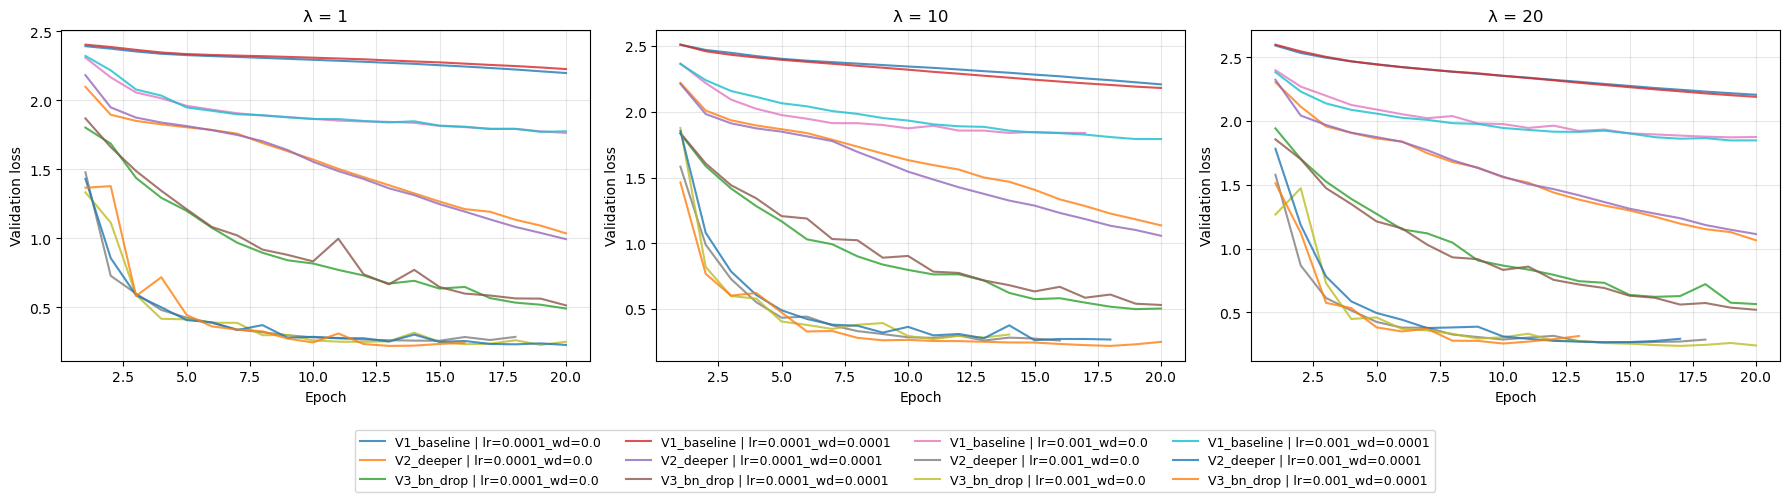

In [17]:
plot_loss_histories_by_lambda_side_by_side(all_results)

### Predictions

In [ ]:
# Get model predictions
@torch.no_grad()
def predict_localization(model, X, C=10, pc_threshold=0.5):
    
    model.eval()
    y_pred = model(X)  

    pc_logit = y_pred[:, 0]
    pc_prob = torch.sigmoid(pc_logit)
    pc_pred = pc_prob > pc_threshold

    bbox_pred = torch.sigmoid(y_pred[:, 1:5])     
    class_logits = y_pred[:, 5:5+C]                
    class_probs = torch.softmax(class_logits, dim=1)
    class_pred = torch.argmax(class_logits, dim=1)

    # Objectness prob, objectness boolean prediction, predicted b-boxes, predicted class and class prob
    return pc_prob, pc_pred, bbox_pred, class_pred, class_probs

In [ ]:
@torch.no_grad()
def predict_on_loader(model, loader, device, C=10, pc_threshold=0.5):
    
    model.eval()

    # Collect prob and predictions
    pc_probs = []
    pc_preds = []
    bbox_preds = []
    class_preds = []
    y_trues = []

    # Iterate over batches 
    for X, y in loader:
        X = X.to(device)
        pc_prob, pc_pred, bbox_pred, class_pred, _ = predict_localization(
            model, X, C=C, pc_threshold=pc_threshold
        )

        pc_probs.append(pc_prob.cpu())
        pc_preds.append(pc_pred.cpu())
        bbox_preds.append(bbox_pred.cpu())
        class_preds.append(class_pred.cpu())
        y_trues.append(y.cpu())

    # Concatenate batch outputs into single tensors covering the full dataset
    return (torch.cat(pc_probs),
            torch.cat(pc_preds),
            torch.cat(bbox_preds),
            torch.cat(class_preds),
            torch.cat(y_trues))

In [ ]:
# Plot the predictions

@torch.no_grad()
def plot_predictions(model, dataset, device, n=12, cols=4, C=10, pc_threshold=0.5):
    model.eval()
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*4))
    axes = np.array(axes).reshape(-1)

    for i in range(rows * cols):
        ax = axes[i]
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_axis_off()

        if i >= n:
            ax.set_visible(False)
            continue

        x, y = dataset[i]
        img = x.squeeze(0).numpy()
        pc_t, cx_t, cy_t, w_t, h_t, c_t = y.tolist()

        X = x.unsqueeze(0).to(device)
        pc_prob, pc_pred, bbox_p, c_pred, _ = predict_localization(model, X, C=C, pc_threshold=pc_threshold)

        pc_p = float(pc_prob.item())
        det = bool(pc_pred.item())
        cx_p, cy_p, w_p, h_p = bbox_p[0].cpu().numpy().tolist()
        c_p = int(c_pred.item())

        H, W = img.shape
        ax.imshow(img, cmap="gray", interpolation="nearest")

        ax.set_title(
            f"true: c={int(c_t)} pc={int(pc_t)} | pred: c={c_p} pc={pc_p:.2f}",
            fontsize=10
        )

        # red frame around each subplot
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(2.0)
            spine.set_edgecolor("red")

        # TRUE bbox (solid)
        if pc_t > 0.5:
            x1 = (cx_t - w_t/2) * W
            y1 = (cy_t - h_t/2) * H
            ax.add_patch(patches.Rectangle(
                (x1, y1), w_t*W, h_t*H,
                fill=False, linewidth=2.5, edgecolor="red", linestyle="-"
            ))

        # PRED bbox (dashed) only if detected
        if det:
            x1 = (cx_p - w_p/2) * W
            y1 = (cy_p - h_p/2) * H
            ax.add_patch(patches.Rectangle(
                (x1, y1), w_p*W, h_p*H,
                fill=False, linewidth=2.5, edgecolor="red", linestyle="--"
            ))

    plt.tight_layout()
    plt.show()

### Model selection and evaluation

In [ ]:
# Convert to center-size format to corner format
def xywh_to_xyxy(xywh):
    
    cx = xywh[..., 0]
    cy = xywh[..., 1]
    w  = xywh[..., 2]
    h  = xywh[..., 3]

    x1 = cx - w / 2
    y1 = cy - h / 2
    x2 = cx + w / 2
    y2 = cy + h / 2

    return torch.stack([x1, y1, x2, y2], dim=-1)

In [ ]:
# Compute intersection over two b-boxes

def intersection(bb1, bb2):
   
    x1 = max(bb1[0], bb2[0])
    y1 = max(bb1[1], bb2[1])
    x2 = min(bb1[2], bb2[2])
    y2 = min(bb1[3], bb2[3])

    w = max(0.0, x2 - x1)
    h = max(0.0, y2 - y1)

    return w * h

In [ ]:
# Compute the intersection area between two bounding boxes and the union area to get IoU

def IoU(bb1, bb2):
    
    inter = intersection(bb1, bb2)

    area1 = max(0.0, bb1[2] - bb1[0]) * max(0.0, bb1[3] - bb1[1])
    area2 = max(0.0, bb2[2] - bb2[0]) * max(0.0, bb2[3] - bb2[1])

    union = area1 + area2 - inter

    if union <= 0:
        return 0.0

    return inter / union

In [ ]:
# Compte the performance on IoU of the model for the given dataset

@torch.no_grad()
def compute_IoU_localization(model, loader, preprocessor=None):
    
    model.eval()
    device = next(model.parameters()).device

    total_iou = 0.0
    n_obj = 0

    for X, y in loader:
        X = X.to(device)
        y = y.to(device)

        if preprocessor is not None:
            X = preprocessor(X)

        y_pred = model(X)

        pc_true = y[:, 0]
        bbox_true = y[:, 1:5]
        has_obj = pc_true > 0.5

        # predictions
        pc_prob = torch.sigmoid(y_pred[:, 0])
        pc_pred = pc_prob > 0.5
        bbox_pred = torch.sigmoid(y_pred[:, 1:5])

        # only images where there is truly an object
        idx = torch.where(has_obj)[0]
        n_obj += len(idx)

        for i in idx:
            if pc_pred[i]:
                bb_true = xywh_to_xyxy(bbox_true[i]).detach().cpu().tolist()
                bb_pred = xywh_to_xyxy(bbox_pred[i]).detach().cpu().tolist()
                total_iou += IoU(bb_true, bb_pred)
            else:
                total_iou += 0.0

    if n_obj == 0:
        return 0.0

    return total_iou / n_obj

In [ ]:
# Compute the accuracy performance of the model for the given dataset

@torch.no_grad()
def compute_accuracy_localization(model, loader, preprocessor=None):
    
    model.eval()
    device = next(model.parameters()).device

    n_correct = 0
    n_obj = 0

    for X, y in loader:
        X = X.to(device)
        y = y.to(device)

        if preprocessor is not None:
            X = preprocessor(X)

        y_pred = model(X)

        pc_true = y[:, 0]
        c_true = y[:, 5].long()

        has_obj = pc_true > 0.5
        n_obj += has_obj.sum().item()

        pc_prob = torch.sigmoid(y_pred[:, 0])
        pc_pred = pc_prob > 0.5

        class_logits = y_pred[:, 5:]
        c_pred = torch.argmax(class_logits, dim=1)

        correct = has_obj & pc_pred & (c_pred == c_true)
        n_correct += correct.sum().item()

    if n_obj == 0:
        return 0.0

    return n_correct / n_obj

In [ ]:
# Compute the overall localization performance
def compute_overall_localization(model, loader, preprocessor=None):
    acc = compute_accuracy_localization(model, loader, preprocessor)
    iou = compute_IoU_localization(model, loader, preprocessor)
    overall = 0.5 * (acc + iou)
    return acc, iou, overall

In [ ]:
# Compute the mAP for a single-object localization model
@torch.no_grad()
def compute_map_localization(model, loader, preprocessor=None, num_classes=10, iou_thresh=0.5):
    
    model.eval()
    device = next(model.parameters()).device

    # For each class, store:
    #   scores[c] = confidence score for predictions of class c
    #   tps[c]    = 1 if TP else 0
    #   fps[c]    = 1 if FP else 0
    scores = {c: [] for c in range(num_classes)}
    tps = {c: [] for c in range(num_classes)}
    fps = {c: [] for c in range(num_classes)}

    # Number of GT objects per class
    n_gt = {c: 0 for c in range(num_classes)}

    for X, y in loader:
        X = X.to(device)
        y = y.to(device)

        if preprocessor is not None:
            X = preprocessor(X)

        y_pred = model(X)

        pc_true = y[:, 0] > 0.5
        bbox_true = y[:, 1:5]
        cls_true = y[:, 5].long()

        pc_prob = torch.sigmoid(y_pred[:, 0])
        bbox_pred = torch.sigmoid(y_pred[:, 1:5])

        class_logits = y_pred[:, 5:]
        class_probs = torch.softmax(class_logits, dim=1)
        cls_pred = torch.argmax(class_probs, dim=1)

        batch_size = X.shape[0]

        # Count GTs
        for i in range(batch_size):
            if pc_true[i]:
                n_gt[int(cls_true[i].item())] += 1

        # Each image contributes at most one prediction:
        # the predicted class with score = pc_prob * max_class_prob
        for i in range(batch_size):
            pred_c = int(cls_pred[i].item())
            pred_score = float((pc_prob[i] * class_probs[i, pred_c]).item())

            # Determine if TP or FP for predicted class
            is_tp = 0
            is_fp = 1

            if pc_true[i]:
                true_c = int(cls_true[i].item())
                if pred_c == true_c:
                    bb_true = xywh_to_xyxy(bbox_true[i]).detach().cpu().tolist()
                    bb_pred = xywh_to_xyxy(bbox_pred[i]).detach().cpu().tolist()
                    iou = IoU(bb_true, bb_pred)
                    if iou >= iou_thresh:
                        is_tp = 1
                        is_fp = 0

            scores[pred_c].append(pred_score)
            tps[pred_c].append(is_tp)
            fps[pred_c].append(is_fp)

    # Compute AP per class
    ap_per_class = {}

    for c in range(num_classes):
        if n_gt[c] == 0:
            ap_per_class[c] = np.nan
            continue

        if len(scores[c]) == 0:
            ap_per_class[c] = 0.0
            continue

        cls_scores = np.array(scores[c])
        cls_tps = np.array(tps[c])
        cls_fps = np.array(fps[c])

        order = np.argsort(-cls_scores)
        cls_tps = cls_tps[order]
        cls_fps = cls_fps[order]

        cum_tp = np.cumsum(cls_tps)
        cum_fp = np.cumsum(cls_fps)

        recalls = cum_tp / n_gt[c]
        precisions = cum_tp / np.maximum(cum_tp + cum_fp, 1e-12)

        # VOC-style AP: precision envelope + area under PR curve
        mrec = np.concatenate(([0.0], recalls, [1.0]))
        mpre = np.concatenate(([0.0], precisions, [0.0]))

        for i in range(len(mpre) - 1, 0, -1):
            mpre[i - 1] = max(mpre[i - 1], mpre[i])

        idx = np.where(mrec[1:] != mrec[:-1])[0]
        ap = np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1])

        ap_per_class[c] = float(ap)

    valid_aps = [ap for ap in ap_per_class.values() if not np.isnan(ap)]
    mAP = float(np.mean(valid_aps)) if len(valid_aps) > 0 else 0.0

    return mAP, ap_per_class

In [ ]:
# Grid search for best model, checking all possible combination

results = {}

for lambda_bbox, hp_dict in all_results.items():
    results[lambda_bbox] = {}

    for hp_key, model_dict in hp_dict.items():
        results[lambda_bbox][hp_key] = {}

        for name, info in model_dict.items():
            model = info["model"]

            acc, iou, overall = compute_overall_localization(
                model, val_loader, preprocessor=None
            )

            mAP, ap_per_class = compute_map_localization(
                model, val_loader, preprocessor=None, num_classes=10, iou_thresh=0.5
            )

            results[lambda_bbox][hp_key][name] = {
                "acc": acc,
                "iou": iou,
                "overall": overall,
                "mAP": mAP,
                "ap_per_class": ap_per_class,
                "lr": info["lr"],
                "weight_decay": info["weight_decay"],
                "lambda_bbox": info["lambda_bbox"],
            }

            print(
                f"lambda={lambda_bbox} | {hp_key} | {name}: "
                f"acc={acc:.4f}, IoU={iou:.4f}, overall={overall:.4f}, mAP@0.5={mAP:.4f}"
            )

lambda=1 | lr=0.0001_wd=0.0 | V1_baseline: acc=0.1703, IoU=0.3705, overall=0.2704, mAP@0.5=0.0035
lambda=1 | lr=0.0001_wd=0.0 | V2_deeper: acc=0.6227, IoU=0.5561, overall=0.5894, mAP@0.5=0.2567
lambda=1 | lr=0.0001_wd=0.0 | V3_bn_drop: acc=0.8312, IoU=0.5180, overall=0.6746, mAP@0.5=0.3635
lambda=1 | lr=0.0001_wd=0.0001 | V1_baseline: acc=0.1610, IoU=0.3763, overall=0.2687, mAP@0.5=0.0040
lambda=1 | lr=0.0001_wd=0.0001 | V2_deeper: acc=0.6405, IoU=0.5696, overall=0.6051, mAP@0.5=0.2884
lambda=1 | lr=0.0001_wd=0.0001 | V3_bn_drop: acc=0.8162, IoU=0.5971, overall=0.7066, mAP@0.5=0.5520
lambda=1 | lr=0.001_wd=0.0 | V1_baseline: acc=0.2907, IoU=0.4629, overall=0.3768, mAP@0.5=0.0214
lambda=1 | lr=0.001_wd=0.0 | V2_deeper: acc=0.9153, IoU=0.5806, overall=0.7479, mAP@0.5=0.5334
lambda=1 | lr=0.001_wd=0.0 | V3_bn_drop: acc=0.9287, IoU=0.4615, overall=0.6951, mAP@0.5=0.2421
lambda=1 | lr=0.001_wd=0.0001 | V1_baseline: acc=0.2878, IoU=0.4296, overall=0.3587, mAP@0.5=0.0165
lambda=1 | lr=0.001_w

In [ ]:
# Retrieve best hyperparameters per model

best_per_model = {}

for lambda_bbox, hp_dict in results.items():
    for hp_key, model_dict in hp_dict.items():
        for name, metrics in model_dict.items():
            overall = metrics["overall"]

            if name not in best_per_model or overall > best_per_model[name]["overall"]:
                best_per_model[name] = {
                    "overall": overall,
                    "lambda_bbox": lambda_bbox,
                    "hp_key": hp_key,
                    "metrics": metrics,
                }


Model: V1_baseline
Best lambda_bbox: 20
Best hyperparams: lr=0.001_wd=0.0001
Metrics: {'acc': 0.2793333333333333, 'iou': 0.5299043517218989, 'overall': 0.4046188425276161, 'mAP': 0.037927768256306164, 'ap_per_class': {0: 0.07818815908808219, 1: 0.027541459581791397, 2: 0.020005435401528666, 3: 0.04432532410899203, 4: 0.05308183581903328, 5: 0.05861389268344816, 6: 0.03348876874407323, 7: 0.0359958537086813, 8: 0.02693712263216916, 9: 0.0010998307952622673}, 'lr': 0.001, 'weight_decay': 0.0001, 'lambda_bbox': 20}
Predictions on training set:


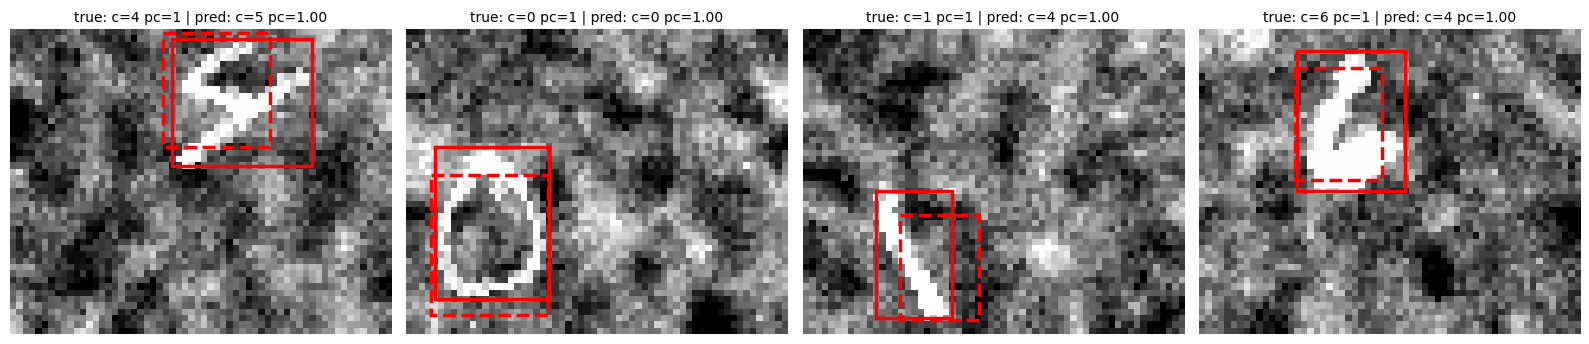

Predictions on validation set:


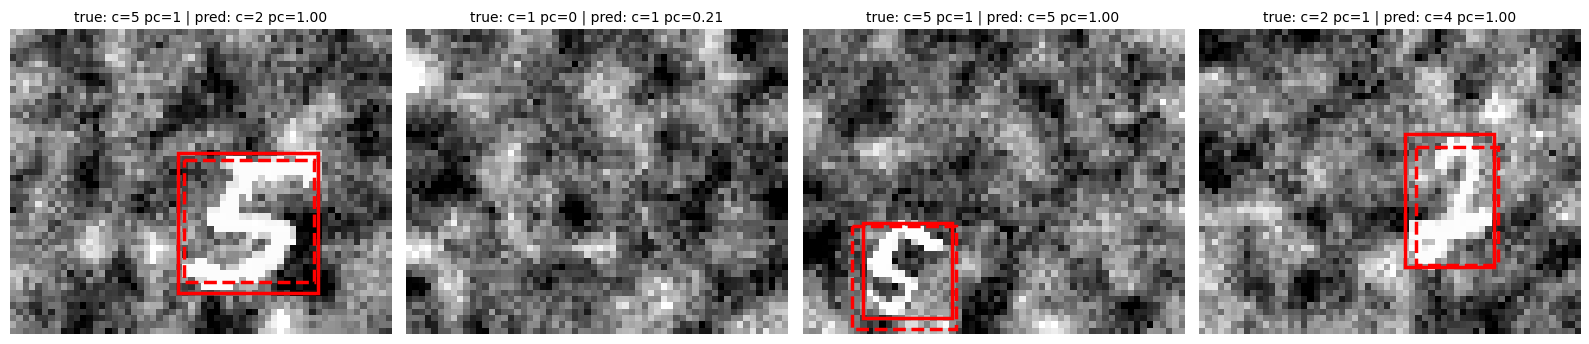


Model: V2_deeper
Best lambda_bbox: 20
Best hyperparams: lr=0.001_wd=0.0
Metrics: {'acc': 0.918, 'iou': 0.713459658619154, 'overall': 0.8157298293095769, 'mAP': 0.8540268228646252, 'ap_per_class': {0: 0.9557635830049683, 1: 0.6774087744081307, 2: 0.8862659968862584, 3: 0.8819875022587845, 4: 0.867064929582258, 5: 0.8649222351300746, 6: 0.8629607081738773, 7: 0.8867053322238508, 8: 0.809759795372623, 9: 0.8474293716054261}, 'lr': 0.001, 'weight_decay': 0.0, 'lambda_bbox': 20}
Predictions on training set:


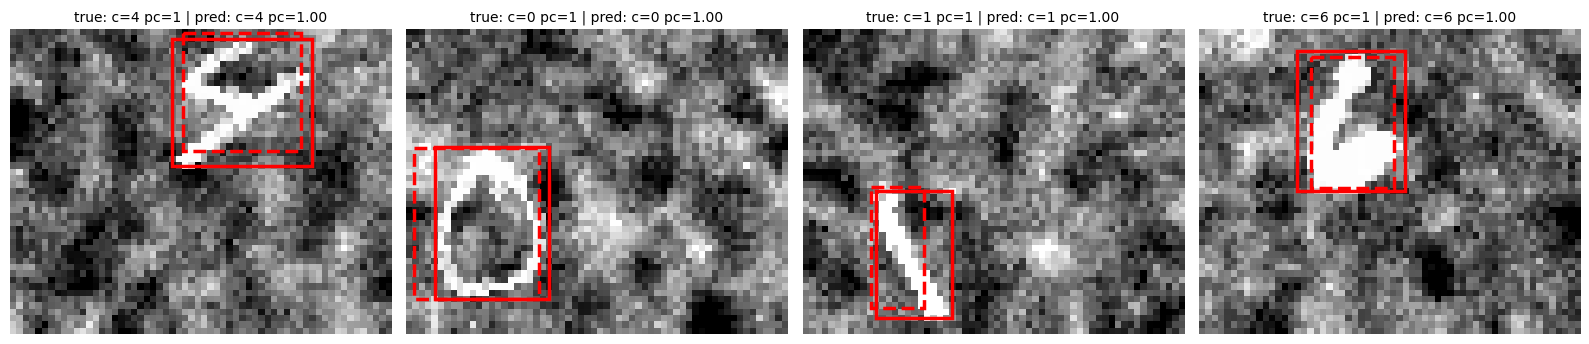

Predictions on validation set:


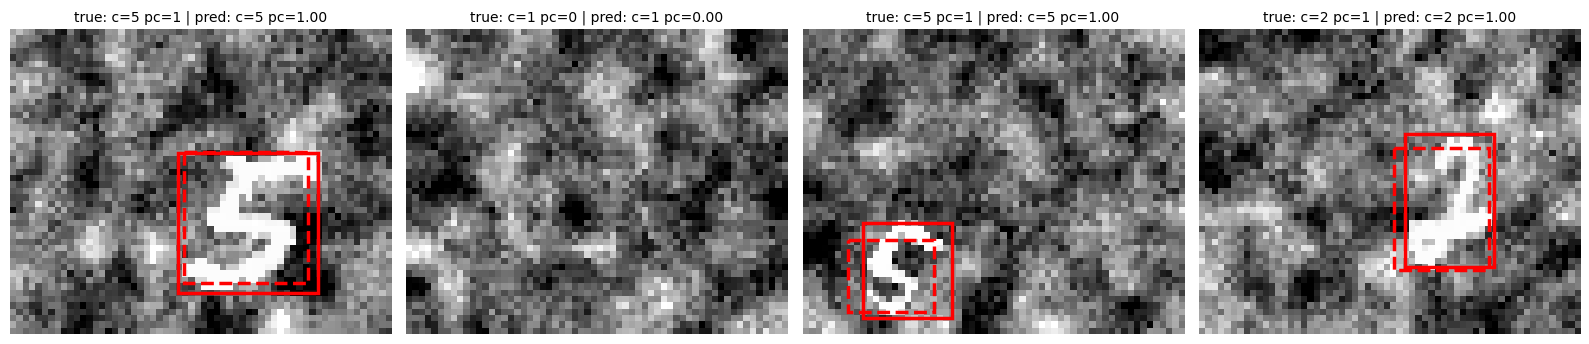


Model: V3_bn_drop
Best lambda_bbox: 10
Best hyperparams: lr=0.001_wd=0.0001
Metrics: {'acc': 0.9333333333333333, 'iou': 0.6839198169192314, 'overall': 0.8086265751262824, 'mAP': 0.8356265262510811, 'ap_per_class': {0: 0.9295984298527402, 1: 0.630793276576173, 2: 0.8603018903536892, 3: 0.8796992996006029, 4: 0.8667252483367759, 5: 0.7834029475661741, 6: 0.8798293606939347, 7: 0.8843627049789934, 8: 0.8437366958788818, 9: 0.7978154086728474}, 'lr': 0.001, 'weight_decay': 0.0001, 'lambda_bbox': 10}
Predictions on training set:


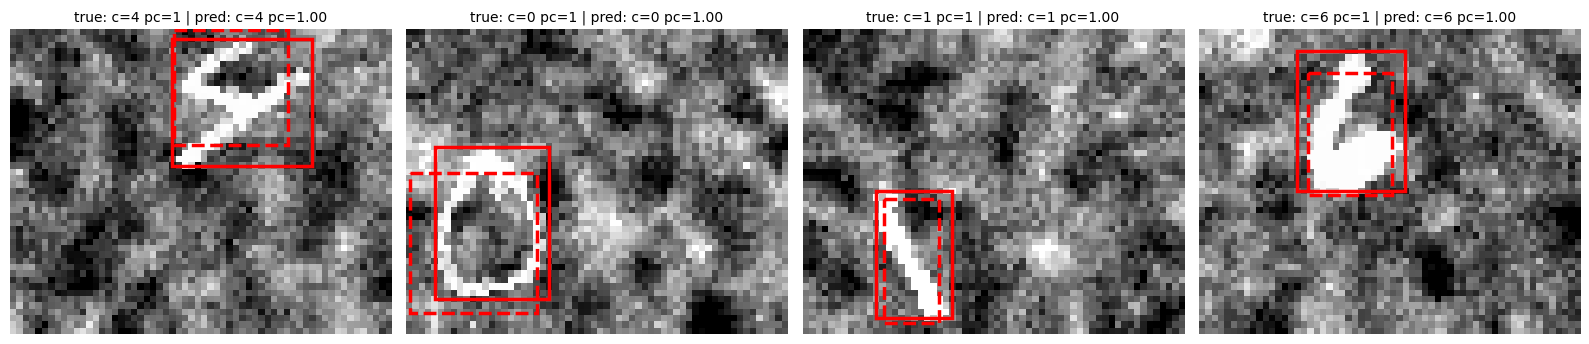

Predictions on validation set:


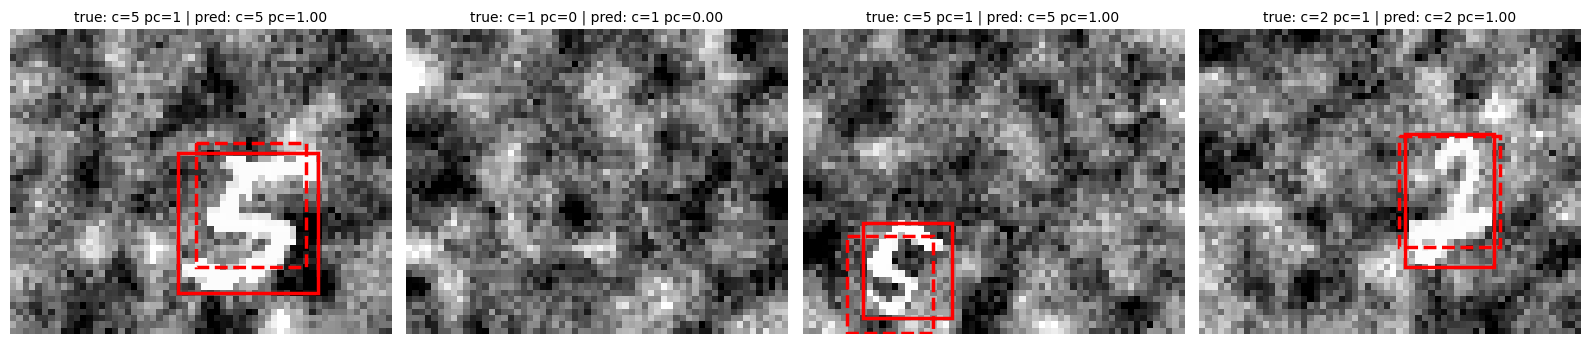

In [ ]:
# Get model stats + vizualise on training and validation set

for name, info in best_per_model.items():
    best_lambda = info["lambda_bbox"]
    best_hp = info["hp_key"]
    best_model = all_results[best_lambda][best_hp][name]["model"]

    print(f"\nModel: {name}")
    print(f"Best lambda_bbox: {best_lambda}")
    print(f"Best hyperparams: {best_hp}")
    print(f"Metrics: {info['metrics']}")

    print("Predictions on training set:")
    plot_predictions(
        model=best_model,
        dataset=train_ds_norm,   
        device=device,
        n=4,
        cols=4,
        C=10,
        pc_threshold=0.5
    )

    print("Predictions on validation set:")
    plot_predictions(
        model=best_model,
        dataset=val_ds_norm,   
        device=device,
        n=4,
        cols=4,
        C=10,
        pc_threshold=0.5
    )

In [ ]:
# Retrieve best model

best_lambda = None
best_hp = None
best_name = None
best_overall = -1

for lambda_bbox, hp_dict in results.items():
    for hp_key, model_dict in hp_dict.items():
        for name, metrics in model_dict.items():
            if metrics["overall"] > best_overall:
                best_overall = metrics["overall"]
                best_lambda = lambda_bbox
                best_hp = hp_key
                best_name = name

best_model = all_results[best_lambda][best_hp][best_name]["model"]

print(f"\nBest model: {best_name}")
print(f"Best lambda_bbox: {best_lambda}")
print(f"Best hyperparams: {best_hp}")
print(results[best_lambda][best_hp][best_name])


Best model: V2_deeper
Best lambda_bbox: 20
Best hyperparams: lr=0.001_wd=0.0
{'acc': 0.918, 'iou': 0.713459658619154, 'overall': 0.8157298293095769, 'mAP': 0.8540268228646252, 'ap_per_class': {0: 0.9557635830049683, 1: 0.6774087744081307, 2: 0.8862659968862584, 3: 0.8819875022587845, 4: 0.867064929582258, 5: 0.8649222351300746, 6: 0.8629607081738773, 7: 0.8867053322238508, 8: 0.809759795372623, 9: 0.8474293716054261}, 'lr': 0.001, 'weight_decay': 0.0, 'lambda_bbox': 20}


### Testing

In [ ]:
# Test the chosen model on the test set

best_lambda, best_hp, best_name = max(
    (
        (lb, hp, name)
        for lb in results
        for hp in results[lb]
        for name in results[lb][hp]
    ),
    key=lambda x: results[x[0]][x[1]][x[2]]["overall"]
)

best_model = all_results[best_lambda][best_hp][best_name]["model"]

test_acc, test_iou, test_overall = compute_overall_localization(
    best_model, test_loader, preprocessor=None
)

test_map, ap_per_class = compute_map_localization(
    best_model, test_loader, preprocessor=None, num_classes=10, iou_thresh=0.5
)

print(f"Best model: {best_name}")
print(f"Best lambda_bbox: {best_lambda}")
print(f"Best hyperparams: {best_hp}")
print(
    f"Test set results | acc={test_acc:.4f}, "
    f"IoU={test_iou:.4f}, overall={test_overall:.4f}, mAP@0.5={test_map:.4f}"
)

print("\nAP per class:")
for c, ap in ap_per_class.items():
    print(f"Class {c}: {ap:.4f}")

Best model: V2_deeper
Best lambda_bbox: 20
Best hyperparams: lr=0.001_wd=0.0
Test set results | acc=0.9209, IoU=0.7127, overall=0.8168, mAP@0.5=0.8513

AP per class:
Class 0: 0.9317
Class 1: 0.6720
Class 2: 0.8807
Class 3: 0.8969
Class 4: 0.8582
Class 5: 0.8680
Class 6: 0.8857
Class 7: 0.8605
Class 8: 0.7961
Class 9: 0.8635


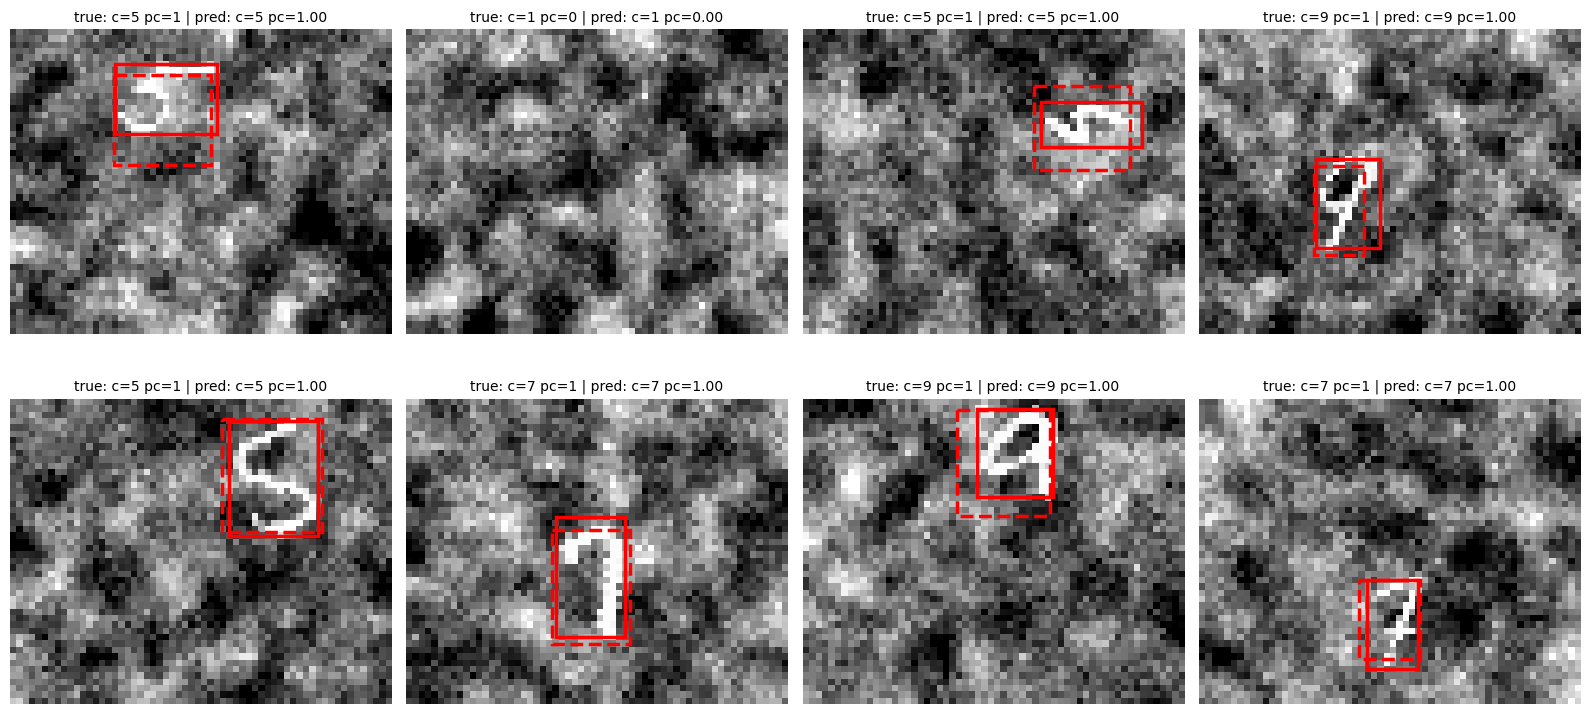

In [34]:
plot_predictions(best_model, test_ds_norm, device, n=8, cols=4, C=10)

In [ ]:
NUM_CLASSES = 10
BBOX_DIM = 5   

# Split the outputs for evaluation
def split_outputs(out):
    class_logits = out[:, :NUM_CLASSES]
    bbox_pred = out[:, NUM_CLASSES:NUM_CLASSES+BBOX_DIM]
    return class_logits, bbox_pred

In [ ]:

# Evaluate the digit accuracy
def evaluate_digit_accuracy(model, dataloader, device, num_classes=10, bbox_dim=5):
    model.eval()

    all_true_cls = []
    all_pred_cls = []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            y = y.to(device)

            out = model(x)

            
            class_logits = out[:, bbox_dim:bbox_dim + num_classes]

            present = y[:, 0] == 1
            true_cls = y[:, 5].long()
            pred_cls = torch.argmax(class_logits, dim=1)

            all_true_cls.append(true_cls[present].cpu())
            all_pred_cls.append(pred_cls[present].cpu())

    all_true_cls = torch.cat(all_true_cls).numpy()
    all_pred_cls = torch.cat(all_pred_cls).numpy()

    overall_acc = accuracy_score(all_true_cls, all_pred_cls)
    cm = confusion_matrix(all_true_cls, all_pred_cls, labels=list(range(num_classes)))

    per_digit_acc = {}
    per_digit_counts = {}

    for d in range(num_classes):
        mask = all_true_cls == d
        per_digit_counts[d] = int(mask.sum())
        per_digit_acc[d] = (
            float((all_pred_cls[mask] == d).mean()) if mask.sum() > 0 else np.nan
        )

    return {
        "overall_accuracy": overall_acc,
        "per_digit_accuracy": per_digit_acc,
        "per_digit_counts": per_digit_counts,
        "confusion_matrix": cm,
        "y_true_cls": all_true_cls,
        "y_pred_cls": all_pred_cls,
    }

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        out = best_model(x)
        class_logits = out[:, 5:]
        pred_cls = torch.argmax(class_logits, dim=1)

        print("true:", y[:10, 5].long().cpu().numpy())
        print("pred:", pred_cls[:10].cpu().numpy())
        break

acc_results = evaluate_digit_accuracy(best_model, test_loader, device, num_classes=10)

print("\nAccuracy per digit:")
for d, acc in acc_results["per_digit_accuracy"].items():
    print(f"Digit {d}: {acc:.4f}  (n={acc_results['per_digit_counts'][d]})")

true: [5 1 5 9 5 7 9 7 5 7]
pred: [5 1 5 9 5 7 9 7 5 7]

Accuracy per digit:
Digit 0: 0.9571  (n=980)
Digit 1: 0.9903  (n=1135)
Digit 2: 0.9079  (n=1032)
Digit 3: 0.9307  (n=1010)
Digit 4: 0.9155  (n=982)
Digit 5: 0.9249  (n=892)
Digit 6: 0.9269  (n=958)
Digit 7: 0.9193  (n=1028)
Digit 8: 0.8203  (n=974)
Digit 9: 0.9078  (n=1009)


In [ ]:

# Evaluate the models presence detection
def evaluate_presence_stats(model, dataloader, device, threshold=0.5):
    model.eval()

    all_true_present = []
    all_pred_present = []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            y = y.to(device)

            out = model(x)

            
            pred_present = (torch.sigmoid(out[:, 0]) >= threshold).long()
            true_present = y[:, 0].long()

            all_true_present.append(true_present.cpu())
            all_pred_present.append(pred_present.cpu())

    all_true_present = torch.cat(all_true_present).numpy()
    all_pred_present = torch.cat(all_pred_present).numpy()

    n_total = len(all_pred_present)
    n_pred_empty = int((all_pred_present == 0).sum())
    n_pred_digit = int((all_pred_present == 1).sum())

    n_true_empty = int((all_true_present == 0).sum())
    n_true_digit = int((all_true_present == 1).sum())

    print(f"Total samples: {n_total}")
    print(f"Predicted empty: {n_pred_empty} ({n_pred_empty / n_total:.4f})")
    print(f"Predicted digit present: {n_pred_digit} ({n_pred_digit / n_total:.4f})")
    print(f"True empty: {n_true_empty} ({n_true_empty / n_total:.4f})")
    print(f"True digit present: {n_true_digit} ({n_true_digit / n_total:.4f})")

    return {
        "y_true_present": all_true_present,
        "y_pred_present": all_pred_present,
        "pred_empty_count": n_pred_empty,
        "pred_digit_count": n_pred_digit,
        "true_empty_count": n_true_empty,
        "true_digit_count": n_true_digit,
    }

presence_stats = evaluate_presence_stats(best_model, test_loader, device, threshold=0.5)

Total samples: 11000
Predicted empty: 1013 (0.0921)
Predicted digit present: 9987 (0.9079)
True empty: 1000 (0.0909)
True digit present: 10000 (0.9091)


In [ ]:
# Evaluate the presence

def evaluate_presence(model, dataloader, device, threshold=0.5):
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            y = y.to(device)

            out = model(x)
            pred_present = (torch.sigmoid(out[:, 0]) >= threshold).long()
            true_present = y[:, 0].long()

            y_true.append(true_present.cpu())
            y_pred.append(pred_present.cpu())

    y_true = torch.cat(y_true).numpy()
    y_pred = torch.cat(y_pred).numpy()

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    acc = accuracy_score(y_true, y_pred)

    no_digit_acc = (y_pred[y_true == 0] == 0).mean()
    digit_present_acc = (y_pred[y_true == 1] == 1).mean()

    print("Overall presence accuracy:", acc)
    print("No-digit accuracy:", no_digit_acc)
    print("Digit-present accuracy:", digit_present_acc)
    print("Confusion matrix:\n", cm)

    return {
        "overall_accuracy": acc,
        "no_digit_accuracy": no_digit_acc,
        "digit_present_accuracy": digit_present_acc,
        "confusion_matrix": cm,
        "y_true": y_true,
        "y_pred": y_pred,
    }

presence_results = evaluate_presence(best_model, test_loader, device)

Overall presence accuracy: 0.9988181818181818
No-digit accuracy: 1.0
Digit-present accuracy: 0.9987
Confusion matrix:
 [[1000    0]
 [  13 9987]]


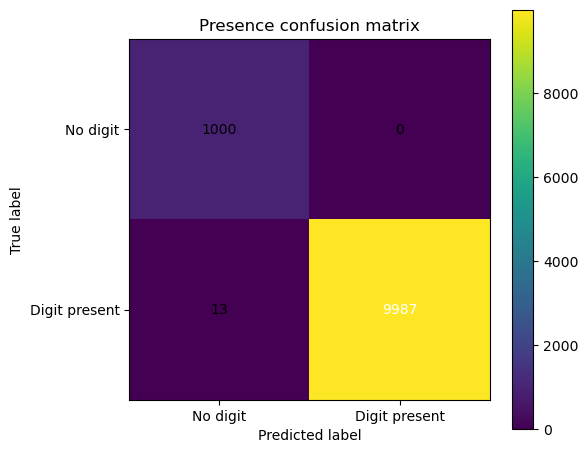

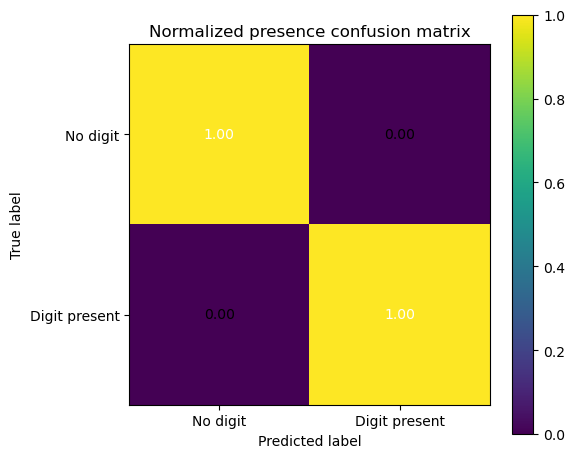

In [ ]:

# Plot presence confusion matrix, normalized and not
def plot_presence_confusion_matrix(results, normalize=False, title="Presence confusion matrix"):
    cm = results["confusion_matrix"]

    if normalize:
        cm = cm.astype(float)
        row_sums = cm.sum(axis=1, keepdims=True)
        cm = np.divide(cm, row_sums, where=row_sums != 0)
        fmt = ".2f"
    else:
        fmt = "d"

    labels = ["No digit", "Digit present"]

    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels)
    plt.yticks(tick_marks, labels)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")

    thresh = cm.max() / 2.0

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = format(cm[i, j], fmt)
            plt.text(
                j, i, value,
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black"
            )

    plt.tight_layout()
    plt.show()

plot_presence_confusion_matrix(presence_results)
plot_presence_confusion_matrix(
    presence_results,
    normalize=True,
    title="Normalized presence confusion matrix"
)

In [40]:
acc_results = evaluate_digit_accuracy(best_model, test_loader, device, num_classes=10)

In [ ]:
# Get accuracy per digit

def plot_per_digit_accuracy(acc_results, title="Classification accuracy on the test set for each digit"):
    digits = list(acc_results["per_digit_accuracy"].keys())
    accuracies = [acc_results["per_digit_accuracy"][d] for d in digits]
    counts = [acc_results["per_digit_counts"][d] for d in digits]

    plt.figure(figsize=(9, 5))
    bars = plt.bar(digits, accuracies)

    plt.ylim(0, 1.05)
    plt.xticks(digits)
    plt.xlabel("Digit")
    plt.ylabel("Accuracy")
    plt.title(title)

    for bar, acc, n in zip(bars, accuracies, counts):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f"{acc:.2f}\n(n={n})",
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.tight_layout()
    plt.show()

In [ ]:
# Accuracy confusion matrix

def plot_confusion_matrix(cm, normalize=False, title="Confusion matrix"):
    if normalize:
        cm = cm.astype(np.float64)
        row_sums = cm.sum(axis=1, keepdims=True)
        cm = np.divide(cm, row_sums, where=row_sums != 0)

    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()

    classes = np.arange(cm.shape[0])
    plt.xticks(classes, classes)
    plt.yticks(classes, classes)
    plt.xlabel("Predicted digit")
    plt.ylabel("True digit")

    fmt = ".2f" if normalize else "d"
    threshold = cm.max() / 2 if cm.size > 0 else 0

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = format(cm[i, j], fmt)
            plt.text(
                j, i, value,
                ha="center", va="center",
                color="white" if cm[i, j] > threshold else "black",
                fontsize=9
            )

    plt.tight_layout()
    plt.show()

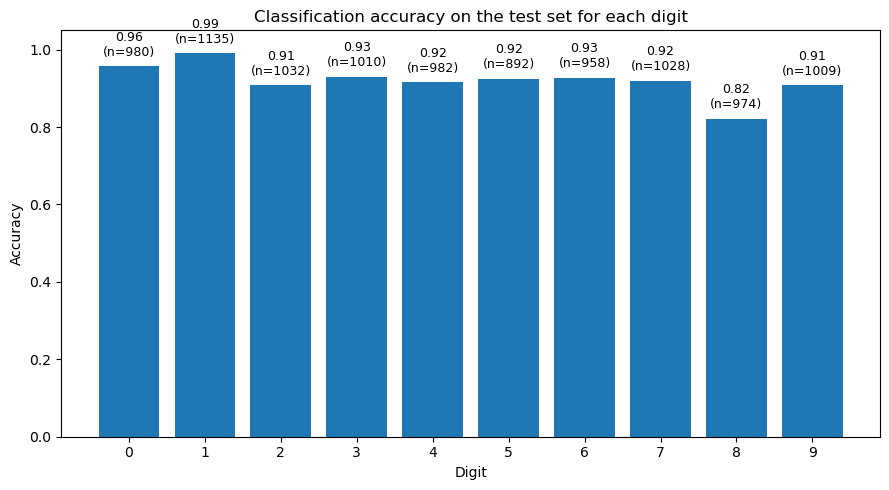

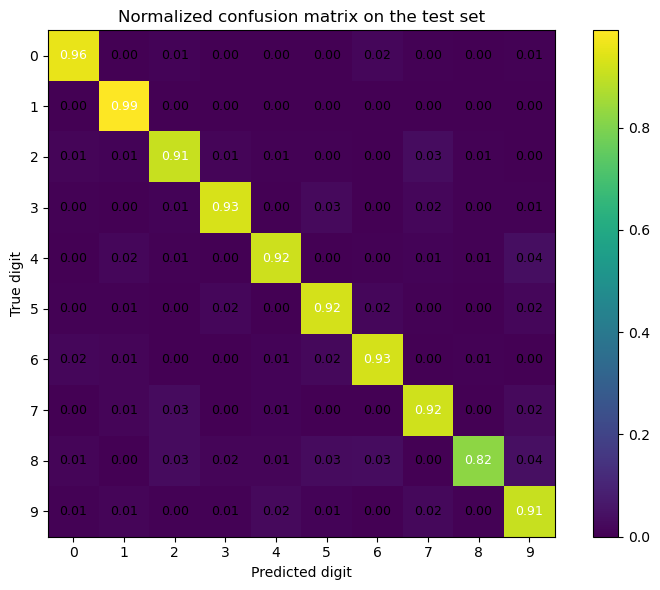

In [43]:
plot_per_digit_accuracy(acc_results)

plot_confusion_matrix(
    acc_results["confusion_matrix"],
    normalize=True,
    title="Normalized confusion matrix on the test set"
)

In [ ]:
# Get IoU per digit

@torch.no_grad()
def compute_IoU_per_digit(model, loader, num_classes=10, preprocessor=None):
    model.eval()
    device = next(model.parameters()).device

    total_iou_per_digit = {d: 0.0 for d in range(num_classes)}
    count_per_digit = {d: 0 for d in range(num_classes)}

    for X, y in loader:
        X = X.to(device)
        y = y.to(device)

        if preprocessor is not None:
            X = preprocessor(X)

        y_pred = model(X)

        # Truth
        pc_true = y[:, 0]
        bbox_true = y[:, 1:5]
        digit_true = y[:, 5].long()

        has_obj = pc_true > 0.5

        # predictions
        pc_prob = torch.sigmoid(y_pred[:, 0])
        pc_pred = pc_prob > 0.5
        bbox_pred = torch.sigmoid(y_pred[:, 1:5])

        idx = torch.where(has_obj)[0]

        for i in idx:
            d = int(digit_true[i].item())
            count_per_digit[d] += 1

            if pc_pred[i]:
                bb_true = xywh_to_xyxy(bbox_true[i]).detach().cpu().tolist()
                bb_pred = xywh_to_xyxy(bbox_pred[i]).detach().cpu().tolist()
                total_iou_per_digit[d] += IoU(bb_true, bb_pred)
            else:
                total_iou_per_digit[d] += 0.0

    mean_iou_per_digit = {}
    for d in range(num_classes):
        if count_per_digit[d] > 0:
            mean_iou_per_digit[d] = total_iou_per_digit[d] / count_per_digit[d]
        else:
            mean_iou_per_digit[d] = np.nan

    return {
        "mean_iou_per_digit": mean_iou_per_digit,
        "count_per_digit": count_per_digit,
    }

In [ ]:
# Plot the IoUs per digit

def plot_IoU_per_digit(iou_results, title="Localization IoU on the test set for each digit"):
    digits = list(iou_results["mean_iou_per_digit"].keys())
    values = [iou_results["mean_iou_per_digit"][d] for d in digits]
    counts = [iou_results["count_per_digit"][d] for d in digits]

    plt.figure(figsize=(9, 5))
    bars = plt.bar(digits, values)

    plt.ylim(0, 1.05)
    plt.xticks(digits)
    plt.xlabel("Digit")
    plt.ylabel("Mean IoU")
    plt.title(title)

    for bar, val, n in zip(bars, values, counts):
        label = f"{val:.2f}\n(n={n})" if not np.isnan(val) else f"nan\n(n={n})"
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            (0 if np.isnan(val) else val) + 0.02,
            label,
            ha="center",
            va="bottom",
            fontsize=9
        )

    plt.tight_layout()
    plt.show()

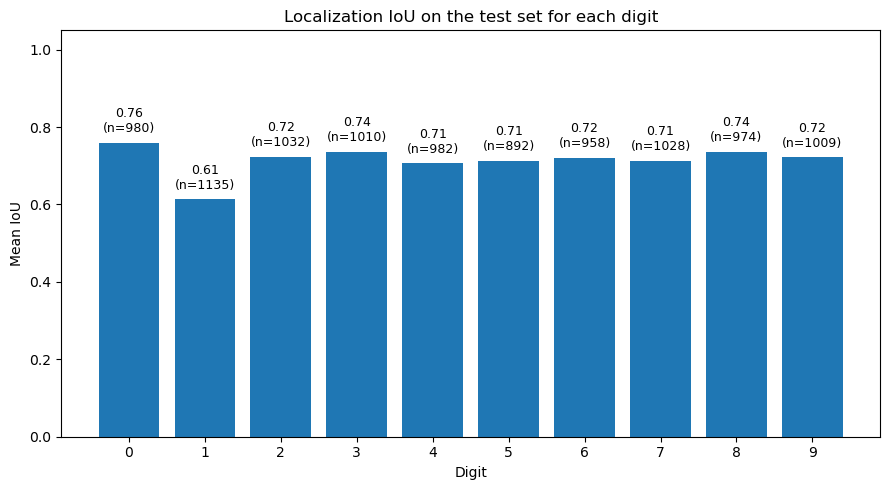

In [46]:
iou_results = compute_IoU_per_digit(best_model, test_loader, num_classes=10)
plot_IoU_per_digit(iou_results)

In [ ]:
# Compute the center bias

@torch.no_grad()
def compute_center_error_per_digit(model, loader, num_classes=10, preprocessor=None):
    model.eval()
    device = next(model.parameters()).device

    dx_per_digit = {d: [] for d in range(num_classes)}
    dy_per_digit = {d: [] for d in range(num_classes)}

    for X, y in loader:
        X = X.to(device)
        y = y.to(device)

        if preprocessor is not None:
            X = preprocessor(X)

        y_pred = model(X)

        pc_true = y[:, 0]
        bbox_true = y[:, 1:5]
        digit_true = y[:, 5].long()

        has_obj = pc_true > 0.5

        pc_prob = torch.sigmoid(y_pred[:, 0])
        pc_pred = pc_prob > 0.5
        bbox_pred = torch.sigmoid(y_pred[:, 1:5])

        idx = torch.where(has_obj)[0]

        for i in idx:
            d = int(digit_true[i].item())

            
            if pc_pred[i]:
                dx = (bbox_pred[i, 0] - bbox_true[i, 0]).item()
                dy = (bbox_pred[i, 1] - bbox_true[i, 1]).item()
                dx_per_digit[d].append(dx)
                dy_per_digit[d].append(dy)

    stats = {}
    for d in range(num_classes):
        if len(dx_per_digit[d]) > 0:
            stats[d] = {
                "dx_mean": np.mean(dx_per_digit[d]),
                "dy_mean": np.mean(dy_per_digit[d]),
                "dx_std": np.std(dx_per_digit[d]),
                "dy_std": np.std(dy_per_digit[d]),
                "n": len(dx_per_digit[d]),
            }
        else:
            stats[d] = {
                "dx_mean": np.nan,
                "dy_mean": np.nan,
                "dx_std": np.nan,
                "dy_std": np.nan,
                "n": 0,
            }

    return stats

In [ ]:
# Plot the center error per digit

def plot_center_error_per_digit(center_stats, title="Localization center bias per digit"):
    digits = list(center_stats.keys())
    dx_means = [center_stats[d]["dx_mean"] for d in digits]
    dy_means = [center_stats[d]["dy_mean"] for d in digits]
    dx_stds = [center_stats[d]["dx_std"] for d in digits]
    dy_stds = [center_stats[d]["dy_std"] for d in digits]

    x = np.arange(len(digits))
    width = 0.35

    plt.figure(figsize=(10, 5))
    plt.bar(x - width/2, dx_means, width, yerr=dx_stds, label="Horizontal error (dx)")
    plt.bar(x + width/2, dy_means, width, yerr=dy_stds, label="Vertical error (dy)")

    plt.axhline(0, color="black", linewidth=1)
    plt.xticks(x, digits)
    plt.xlabel("Digit")
    plt.ylabel("Prediction bias")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

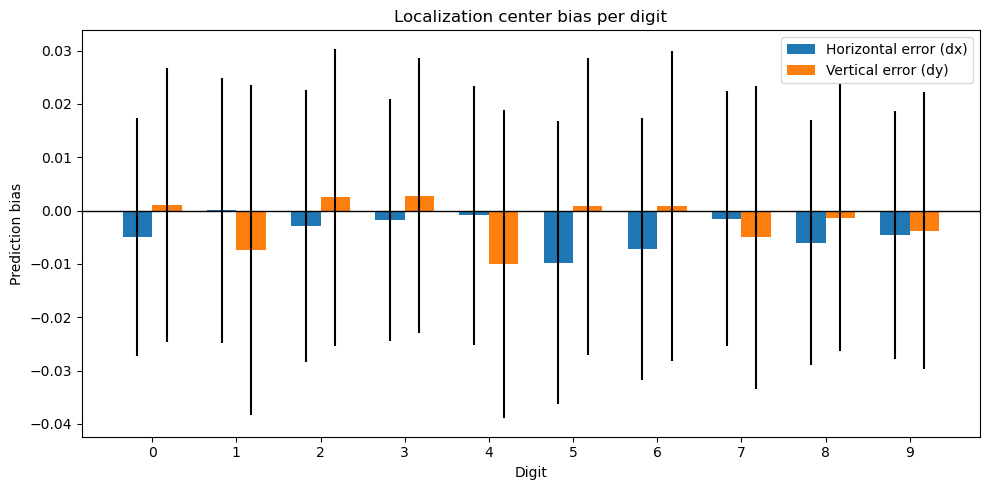

In [49]:
center_stats = compute_center_error_per_digit(best_model, test_loader)
plot_center_error_per_digit(center_stats)